In [5]:
!pip install folium


import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go



plt.rcParams['figure.figsize'] = (10, 12)


import warnings
warnings.filterwarnings('ignore')



In [6]:
pip install --upgrade pip


In [12]:
df = pd.read_excel('Covid cases in India.xlsx')
df_india = df.copy()
df

,S. No.,Name of State / UT,Total Confirmed cases (Indian National),Total Confirmed cases ( Foreign National ),Cured,Death
0,1,Andhra Pradesh,9,0,0,0
1,2,Bihar,3,0,0,1
2,3,Chhattisgarh,1,0,0,0
3,4,Delhi,30,1,6,1
4,5,Gujarat,32,1,0,1
5,6,Haryana,14,14,11,0
6,7,Himachal Pradesh,3,0,0,1
7,8,Karnataka,41,0,3,1
8,9,Kerala,101,8,4,0
9,10,Madhya Pradesh,9,0,0,0


In [13]:
India_coord = pd.read_excel('Indian Coordinates.xlsx')


dbd_India = pd.read_excel('per_day_cases.xlsx',parse_dates=True,sheet_name='India')
dbd_Italy = pd.read_excel('per_day_cases.xlsx',parse_dates=True,sheet_name='Italy')
dbd_Korea = pd.read_excel('per_day_cases.xlsx',parse_dates=True,sheet_name='Korea')


In [14]:
#Analysing Covid 19 cases in india

In [15]:
df['Total_cases'] = df['Total Confirmed cases (Indian National)']+df['Total Confirmed cases ( Foreign National )']
total_cases = df['Total_cases'].sum()


In [16]:
df.style.background_gradient(cmap='Reds')

,S. No.,Name of State / UT,Total Confirmed cases (Indian National),Total Confirmed cases ( Foreign National ),Cured,Death,Total_cases
0,1,Andhra Pradesh,9,0,0,0,9
1,2,Bihar,3,0,0,1,3
2,3,Chhattisgarh,1,0,0,0,1
3,4,Delhi,30,1,6,1,31
4,5,Gujarat,32,1,0,1,33
5,6,Haryana,14,14,11,0,28
6,7,Himachal Pradesh,3,0,0,1,3
7,8,Karnataka,41,0,3,1,41
8,9,Kerala,101,8,4,0,109
9,10,Madhya Pradesh,9,0,0,0,9


In [17]:
df['Total Active'] = df['Total_cases'] - (df['Death'] + df['Cured'])
total_active = df['Total Active'].sum()
print('Total number of active COVID 2019 cases across India:', total_active)

Tot_Cases = df.groupby('Name of State / UT')['Total Active'].sum().sort_values(ascending=False).to_frame()

Total number of active COVID 2019 cases across India: 512


In [18]:
Tot_Cases.style.background_gradient(cmap='Reds')

,Total Active
Name of State / UT,
Kerala,105
Maharashtra,99
Karnataka,37
Telengana,34
Gujarat,32
Rajasthan,29
Punjab,28
Delhi,24
Uttar Pradesh,24


In [19]:
#Confirmed vs Recovered Figures


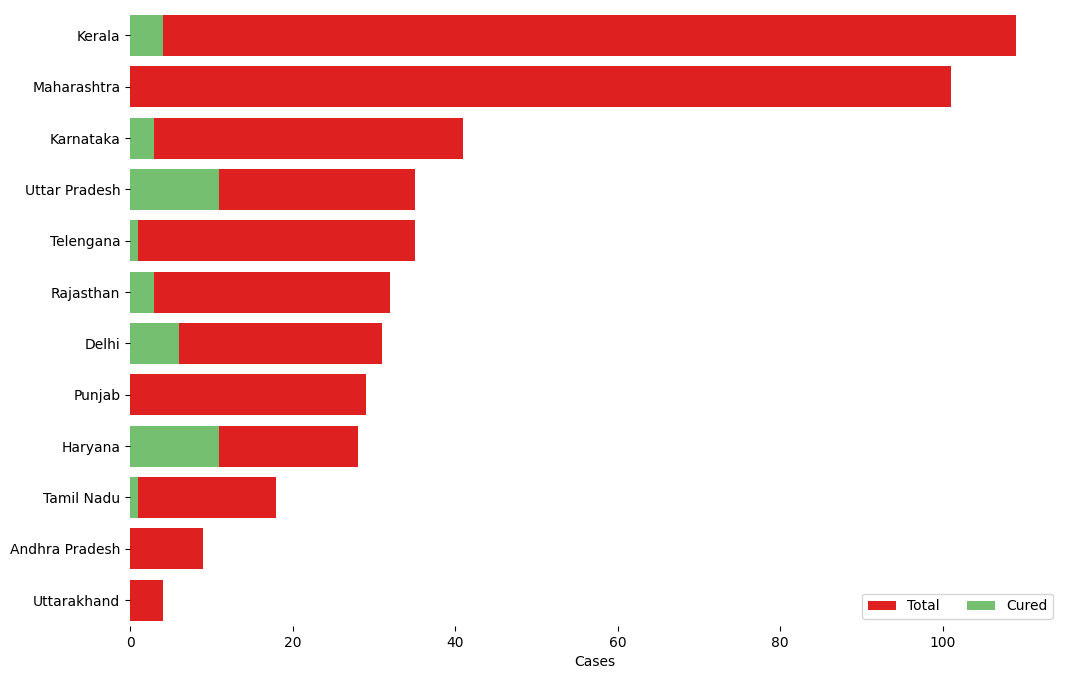

In [20]:
f, ax = plt.subplots(figsize=(12,8))
df_full=pd.merge(India_coord,df,on='Name of State / UT')
data = df_full[['Name of State / UT','Total_cases','Cured','Death']]
data.sort_values('Total_cases',ascending=False,inplace=True)

sns.barplot(x="Total_cases",y="Name of State / UT",data=data,label="Total",color="r")

sns.set_color_codes("muted")
sns.barplot(x="Cured",y="Name of State / UT",data=data,label='Cured',color="g")


ax.legend(ncol=2,loc="lower right",frameon=True)
ax.set(ylabel="",xlabel="Cases")
sns.despine(left=True,bottom=True)
plt.show()


In [21]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=dbd_India['Date'], y=dbd_India['Total Cases'], mode='lines+markers', name='Total cases'))
fig.update_layout(title_text='Trend of Coronavirus Cases in India (Cumulative cases)', plot_bgcolor='rgb(230,230,230)')
fig.show()

fig=px.bar(dbd_India, x="Date", y="New Cases", barmode="group", height=400)
fig.update_layout(title_text="Coronavirus Cases in India on daily basis", plot_bgcolor='rgb(230,230,230)')

fig.show()

In [22]:
#Comparison with cases of Italy and South Korea


In [23]:
fig=px.bar(dbd_India,x="Date",y="Total Cases",color='Total Cases',orientation='v',height=600,title='Confirmed Cases in India',color_discrete_sequence=px.colors.cyclical.IceFire)

fig.update_layout(plot_bgcolor='rgb(230,230,230)')
fig.show()

fig=px.bar(dbd_Italy,x="Date",y="Total Cases",color='Total Cases',orientation='v',height=600,title='Confirmed Cases in Italy',color_discrete_sequence=px.colors.cyclical.IceFire)
fig.update_layout(plot_bgcolor='rgb(230,230,230)')
fig.show()
fig=px.bar(dbd_Korea,x="Date",y="Total Cases",color='Total Cases',orientation='v',height=600,title='Confirmed Cases in South Korea',color_discrete_sequence=px.colors.cyclical.IceFire)
fig.update_layout(plot_bgcolor='rgb(230,230,230)')
fig.show()

In [24]:
#Visualization Inference
#Confirmed Cases in India is rising exponentially
#Confirmed Cases in Italy is rising exponentially
#Confirmed Cases in S korea is rising gradually

In [25]:
from plotly.subplots import make_subplots

fig = make_subplots(rows=2,cols=2,specs=[[{},{}],[{"colspan":2},None]],
                    subplot_titles=("S.Korea","Italy","India"))
fig.add_trace(go.Bar(x=dbd_Korea['Date'],y=dbd_Korea['Total Cases'],marker=dict(color=dbd_Korea['Total Cases'],coloraxis="coloraxis")),1,1)
fig.add_trace(go.Bar(x=dbd_Italy['Date'],y=dbd_Italy['Total Cases'],marker=dict(color=dbd_Italy['Total Cases'],coloraxis="coloraxis")),1,2)
fig.add_trace(go.Bar(x=dbd_India['Date'],y=dbd_India['Total Cases'],marker=dict(color=dbd_India['Total Cases'],coloraxis="coloraxis")),2,1)
fig.update_layout(coloraxis=dict(colorscale='Bluered_r'),showlegend=False,title_text="Total confirmed Cases(Cumulative)")
fig.update_layout(plot_bgcolor='rgb(230,230,230)')
fig.show()

In [27]:
#Part 3:Exploring World Wide data


In [28]:
df = pd.read_csv('covid_19_clean_complete.csv', parse_dates=['Date'])

df.rename(columns={'ObservationDate':'Date','Country/Region':'Country'}, inplace=True)
df_confirmed = pd.read_csv("time_series_covid19_confirmed_global.csv")
df_recovered = pd.read_csv("time_series_covid19_recovered_global.csv")
df_deaths = pd.read_csv("time_series_covid19_deaths_global.csv")

df_confirmed.rename(columns={'Country/Region':'Country'}, inplace=True)
df_recovered.rename(columns={'Country/Region':'Country'}, inplace=True)
df_deaths.rename(columns={'Country/Region':'Country'}, inplace=True)

In [29]:
df_deaths.head()

,Province/State,Country,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,3/15/20,3/16/20,3/17/20,3/18/20,3/19/20,3/20/20,3/21/20,3/22/20,3/23/20,3/24/20
0,NaN,Afghanistan,33.0000,65.0000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
1,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,1,1,1,2,2,2,2,2,4,5
2,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,4,4,4,7,9,11,15,17,17,19
3,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
4,NaN,Angola,-11.2027,17.8739,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
#Check for India's data


In [31]:
df.query('Country=="India"').groupby("Date")[['Confirmed','Deaths','Recovered']].sum().reset_index()

,Date,Confirmed,Deaths,Recovered
0,2020-01-22,0.0,0.0,0.0
1,2020-01-23,0.0,0.0,0.0
2,2020-01-24,0.0,0.0,0.0
3,2020-01-25,0.0,0.0,0.0
4,2020-01-26,0.0,0.0,0.0
...,...,...,...,...
57,2020-03-19,194.0,4.0,15.0
58,2020-03-20,244.0,5.0,20.0
59,2020-03-21,330.0,4.0,23.0
60,2020-03-22,396.0,7.0,27.0


In [32]:
#Visualizing Worldwide NCOVID 19 Cases

In [33]:
confirmed = df.groupby('Date').sum()['Confirmed'].reset_index()
deaths = df.groupby('Date').sum()['Deaths'].reset_index()
recovered = df.groupby('Date').sum()['Recovered'].reset_index()

In [34]:
fig=go.Figure()
#Plotting datewise confirmed cases
fig.add_trace(go.Scatter(x=confirmed['Date'],y=confirmed['Confirmed'],mode='lines+markers',name='Confirmed',line=dict(color='Red',width=2)))
fig.add_trace(go.Scatter(x=deaths['Date'],y=deaths['Deaths'],mode='lines+markers',name='Deaths',line=dict(color='Green',width=2)))
fig.add_trace(go.Scatter(x=recovered['Date'],y=recovered['Recovered'],mode='lines+markers',name='Recovered',line=dict(color='Blue',width=2)))
fig.update_layout(title='Worldwide NCOVID 19 Cases',xaxis_tickfont_size=14,yaxis=dict(title='Number of Cases'))
fig.show()


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

data = dbd_India['Total Cases'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_dataset(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        a = dataset[i:(i + time_step), 0]
        X.append(a)
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 10
X, y = create_dataset(scaled_data, time_step)

X = X.reshape(X.shape[0], X.shape[1], 1)


train_size = int(len(X) * 0.80)
test_size = len(X) - train_size
X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

In [36]:
# Initializing the Model
model = Sequential()

#Adding LSTM Layers
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))

#Output Layer
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# epochs=100 ensures it learns enough, batch_size=64 updates weights every 64 samples
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=100, batch_size=64, verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.0042 - val_loss: 0.3122
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0033 - val_loss: 0.2903
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0028 - val_loss: 0.2691
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0027 - val_loss: 0.2533
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0029 - val_loss: 0.2459
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0029 - val_loss: 0.2442
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0028 - val_loss: 0.2454
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0025 - val_loss: 0.2473
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0024 - val_loss: 0.2484
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0023 - val_loss: 0.2475
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0024 - val_loss: 0.2437
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0024

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 419ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


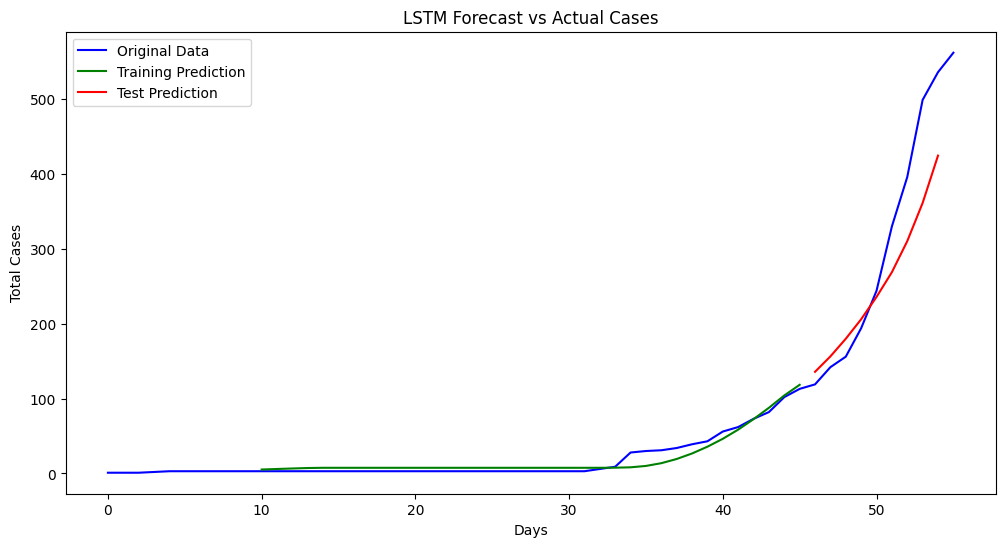

In [37]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(12, 6))

plt.plot(scaler.inverse_transform(scaled_data), label='Original Data', color='blue')

trainPredictPlot = np.empty_like(scaled_data)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[time_step:len(train_predict)+time_step, :] = train_predict
plt.plot(trainPredictPlot, label='Training Prediction', color='green')

testPredictPlot = np.empty_like(scaled_data)
testPredictPlot[:, :] = np.nan

test_start_index = time_step + len(train_predict)
testPredictPlot[test_start_index:test_start_index + len(test_predict), :] = test_predict
plt.plot(testPredictPlot, label='Test Prediction', color='red')

plt.title('LSTM Forecast vs Actual Cases')
plt.xlabel('Days')
plt.ylabel('Total Cases')
plt.legend()
plt.show()

In [38]:
import plotly.graph_objects as go
import numpy as np

trainPlot = np.empty_like(scaled_data)
trainPlot[:, :] = np.nan
trainPlot[time_step:len(train_predict)+time_step, :] = train_predict

testPlot = np.empty_like(scaled_data)
testPlot[:, :] = np.nan
test_start_index = time_step + len(train_predict)
testPlot[test_start_index : test_start_index + len(test_predict), :] = test_predict
actual_cases = scaler.inverse_transform(scaled_data)

fig = go.Figure()

fig.add_trace(go.Scatter(
    y=actual_cases.flatten(),
    mode='lines',
    name='Actual Cases',
    line=dict(color='blue', width=2)
))

fig.add_trace(go.Scatter(
    y=trainPlot.flatten(),
    mode='lines',
    name='Training Predictions',
    line=dict(color='green', width=2)
))


fig.add_trace(go.Scatter(
    y=testPlot.flatten(),
    mode='lines',
    name='Test Predictions',
    line=dict(color='red', width=2)
))

fig.update_layout(
    title='Model Accuracy: LSTM Predictions vs Actual Data',
    xaxis_title='Days',
    yaxis_title='Total Cases',
    template='plotly_white'
)

fig.show()

In [39]:
#Forecasting Total Number of Casaes Worldwide
#Using Prophet

In [40]:
!pip install prophet
from prophet import Prophet

In [41]:
confirmed = df.groupby('Date').sum()['Confirmed'].reset_index()
deaths=df.groupby('Date').sum()['Deaths'].reset_index()
recovered = df.groupby('Date').sum()['Recovered'].reset_index()

In [44]:
confirmed.columns=['ds','y']
#confirmed['ds']=confirmed['ds'].dt.date
confirmed['ds'] = pd.to_datetime(confirmed['ds'])

In [45]:
confirmed.tail()

,ds,y
57,2020-03-19,242708.0
58,2020-03-20,272166.0
59,2020-03-21,304524.0
60,2020-03-22,335955.0
61,2020-03-23,336004.0


In [46]:
#Forecasting Worldwide Cases with Prohet

In [47]:
prophet_df = confirmed.rename(columns={'Date': 'ds', 'Confirmed': 'y'})
m = Prophet(interval_width=0.95)
m.fit(prophet_df)
future = m.make_future_dataframe(periods=7)
future.tail()

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds
64,2020-03-26
65,2020-03-27
66,2020-03-28
67,2020-03-29
68,2020-03-30


In [48]:
forecast = m.predict(future)
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
64,2020-03-26,355136.871697,333998.047649,375709.093012
65,2020-03-27,372235.325605,351079.811701,393227.832921
66,2020-03-28,388674.962752,368333.835786,410848.154964
67,2020-03-29,405307.953232,382286.866793,426701.792687
68,2020-03-30,418529.646985,395348.851016,441969.600786


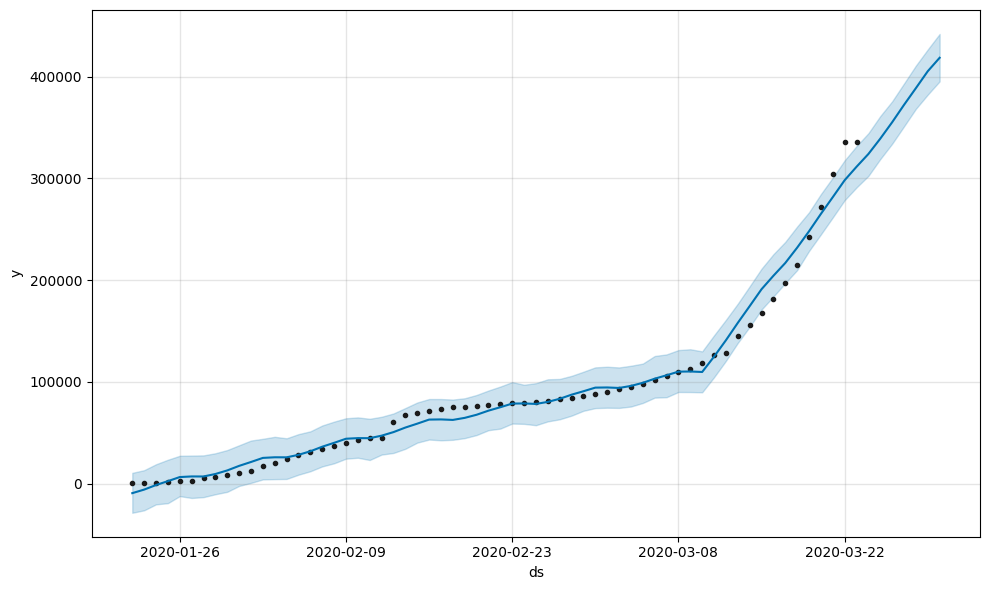

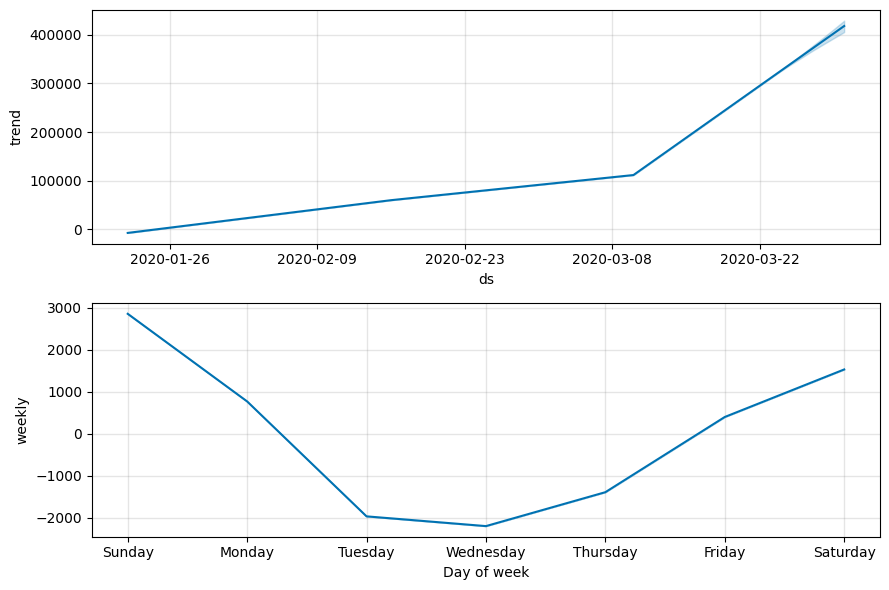

In [49]:
confirmed_forecast_plot = m.plot(forecast)
confirmed_forecast_plot = m.plot_components(forecast)

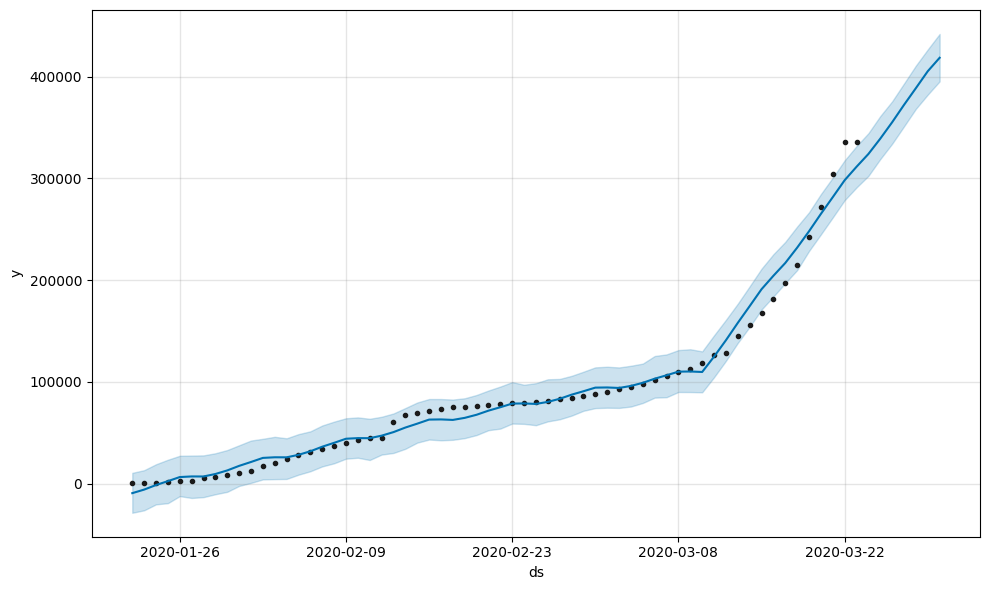

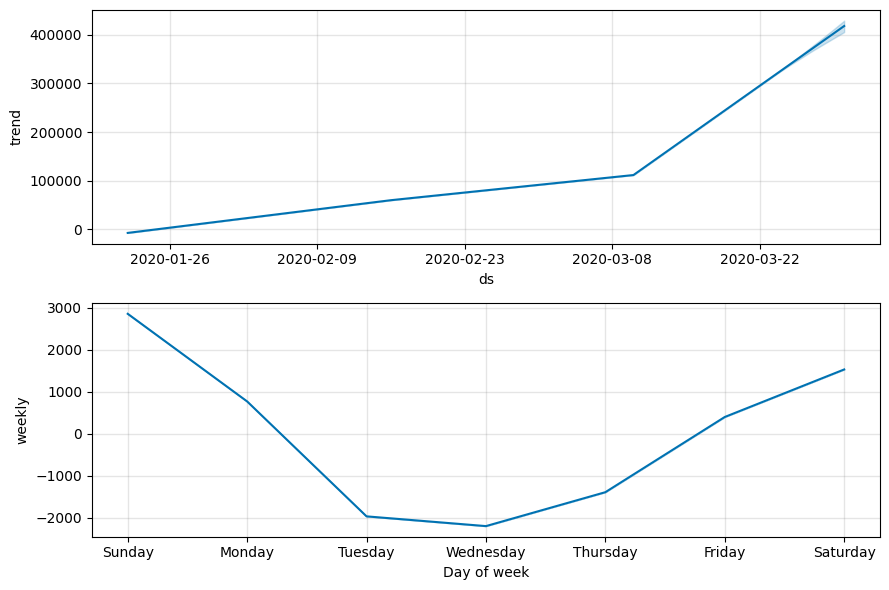

In [50]:
recovered_forecast_plot = m.plot(forecast)
recovered_forecast_plot = m.plot_components(forecast)